# EY Water Quality Forecasting Challenge - Solution
## Challenge Zindi - Prediction de la Qualite de l'Eau en Afrique du Sud

---

**Objectif:** Predire 3 parametres de qualite de l'eau (Total Alkalinity, Electrical Conductance, Dissolved Reactive Phosphorus)  
**Metriques:** R2, RMSE, MAE  
**Donnees:** Landsat + TerraClimate (2011-2015)  
**Evaluation:** Cross-Validation (K-Fold)

---

## Table des matieres

1. [Installation & Imports](#section1)
2. [Chargement des donnees](#section2)
3. [Analyse Exploratoire (EDA)](#section3)
4. [Nettoyage & Preprocessing](#section4)
5. [Feature Engineering](#section5)
6. [Preparation des donnees](#section6)
7. [Modelisation avec Cross-Validation](#section7)
8. [Comparaison des Modeles](#section8)
9. [Feature Importance](#section9)
10. [Entrainement Final & Submission](#section10)

---
## 1. Installation & Imports des bibliotheques {#section1}

In [102]:
# Suppression des warnings pour une meilleure lisibilite
import warnings
warnings.filterwarnings('ignore')

# Manipulation de donnees
import pandas as pd
import numpy as np
from datetime import datetime

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, RobustScaler

# Machine Learning - Modeles
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
import lightgbm as lgb

# Metriques
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Sauvegarde des modeles
import joblib
import os

# Configuration de la visualisation
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Toutes les bibliotheques ont ete importees avec succes!")

Toutes les bibliotheques ont ete importees avec succes!


---
## 2. Chargement des donnees {#section2}

In [103]:
# Chemins des fichiers
DATA_PATH = "./"

# Chargement des datasets
print("Chargement des donnees...")

# Target - Qualite de l'eau (train)
water_quality_train = pd.read_csv(f'{DATA_PATH}water_quality_training_dataset.csv')

# Features - Landsat
landsat_train = pd.read_csv(f'{DATA_PATH}landsat_features_training.csv')
landsat_val = pd.read_csv(f'{DATA_PATH}landsat_features_validation.csv')

# Features - TerraClimate
terraclimate_train = pd.read_csv(f'{DATA_PATH}terraclimate_features_training.csv')
terraclimate_val = pd.read_csv(f'{DATA_PATH}terraclimate_features_validation.csv')

# Template de soumission
submission_template = pd.read_csv(f'{DATA_PATH}submission_template.csv')

print(f"Donnees chargees:")
print(f"   - Water Quality Train: {water_quality_train.shape}")
print(f"   - Landsat Train: {landsat_train.shape}")
print(f"   - Landsat Validation: {landsat_val.shape}")
print(f"   - TerraClimate Train: {terraclimate_train.shape}")
print(f"   - TerraClimate Validation: {terraclimate_val.shape}")
print(f"   - Submission Template: {submission_template.shape}")

Chargement des donnees...
Donnees chargees:
   - Water Quality Train: (9319, 6)
   - Landsat Train: (9319, 9)
   - Landsat Validation: (200, 9)
   - TerraClimate Train: (9319, 4)
   - TerraClimate Validation: (200, 4)
   - Submission Template: (200, 6)


### 2.1 Fusion des datasets

In [104]:
# Fusion des features pour l'entrainement
train_features = pd.merge(
    landsat_train, 
    terraclimate_train, 
    on=['Latitude', 'Longitude', 'Sample Date'],
    how='inner'
)

# Fusion avec les targets
train_data = pd.merge(
    train_features,
    water_quality_train,
    on=['Latitude', 'Longitude', 'Sample Date'],
    how='inner'
)

# Fusion des features pour le test (validation Zindi)
test_features = pd.merge(
    landsat_val, 
    terraclimate_val, 
    on=['Latitude', 'Longitude', 'Sample Date'],
    how='inner'
)

print(f"Datasets fusionnes:")
print(f"   - Train complet: {train_data.shape}")
print(f"   - Test features: {test_features.shape}")

# Apercu des donnees
train_data.head()

Datasets fusionnes:
   - Train complet: (9319, 13)
   - Test features: (200, 10)


,Latitude,Longitude,Sample Date,nir,green,swir16,swir22,NDMI,MNDWI,pet,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-28.760833,17.730278,02-01-2011,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595,174.2,128.912,555.0,10.0
1,-26.861111,28.884722,03-01-2011,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134,124.1,74.720,162.9,163.0
2,-26.450000,28.085833,03-01-2011,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805,127.5,89.254,573.0,80.0
3,-27.671111,27.236944,03-01-2011,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416,129.7,82.000,203.6,101.0
4,-27.356667,27.286389,03-01-2011,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683,129.2,56.100,145.1,151.0


---
## 3. Analyse Exploratoire des Donnees (EDA) {#section3}

### 3.1 Informations generales

In [105]:
# Informations sur le dataset
print("=" * 80)
print("INFORMATIONS GENERALES")
print("=" * 80)
print(f"\nNombre de lignes: {train_data.shape[0]}")
print(f"Nombre de colonnes: {train_data.shape[1]}")
print(f"\nPeriode: {train_data['Sample Date'].min()} -> {train_data['Sample Date'].max()}")
print(f"\nTypes de donnees:")
print(train_data.dtypes)

INFORMATIONS GENERALES

Nombre de lignes: 9319
Nombre de colonnes: 13

Periode: 01-01-2013 -> 31-12-2015

Types de donnees:
Latitude                         float64
Longitude                        float64
Sample Date                       object
nir                              float64
green                            float64
swir16                           float64
swir22                           float64
NDMI                             float64
MNDWI                            float64
pet                              float64
Total Alkalinity                 float64
Electrical Conductance           float64
Dissolved Reactive Phosphorus    float64
dtype: object


In [106]:
# Statistiques descriptives
print("\n" + "=" * 80)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 80)
train_data.describe()


STATISTIQUES DESCRIPTIVES


,Latitude,Longitude,nir,green,swir16,swir22,NDMI,MNDWI,pet,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
count,9319.000000,9319.000000,8234.000000,8234.000000,8234.000000,8234.000000,8234.000000,8234.000000,9319.000000,9319.000000,9319.000000,9319.000000
mean,-28.474988,26.868414,14045.485426,9983.213141,13567.459315,11425.538377,0.021374,-0.144268,175.166082,119.108208,485.004146,43.525338
std,2.760282,3.535164,2953.223626,2778.780177,3348.517657,2548.193535,0.077897,0.097646,29.469867,74.692591,341.937736,50.980194
min,-34.405833,17.730278,3992.000000,4045.000000,3672.500000,3634.000000,-0.328293,-0.300487,52.700000,4.800000,15.120000,5.000000
25%,-30.160091,26.126667,12723.625000,9370.000000,11760.625000,9839.500000,-0.036869,-0.211270,156.100000,55.811000,207.050000,10.000000
50%,-28.058889,27.409060,14183.000000,9801.000000,13704.250000,11265.250000,0.021549,-0.167901,172.500000,113.300000,402.000000,20.000000
75%,-26.861111,29.245556,15513.875000,10286.000000,15425.625000,12895.500000,0.073297,-0.104677,193.100000,170.230000,693.000000,48.000000
max,-22.225556,32.325000,65535.000000,65535.000000,65535.000000,31202.500000,0.567905,0.590974,270.800020,361.676000,1506.000000,195.000000


### 3.2 Valeurs manquantes


VALEURS MANQUANTES
Colonne  Valeurs manquantes  Pourcentage (%)
    nir                1085         11.64288
  green                1085         11.64288
 swir16                1085         11.64288
 swir22                1085         11.64288
   NDMI                1085         11.64288
  MNDWI                1085         11.64288


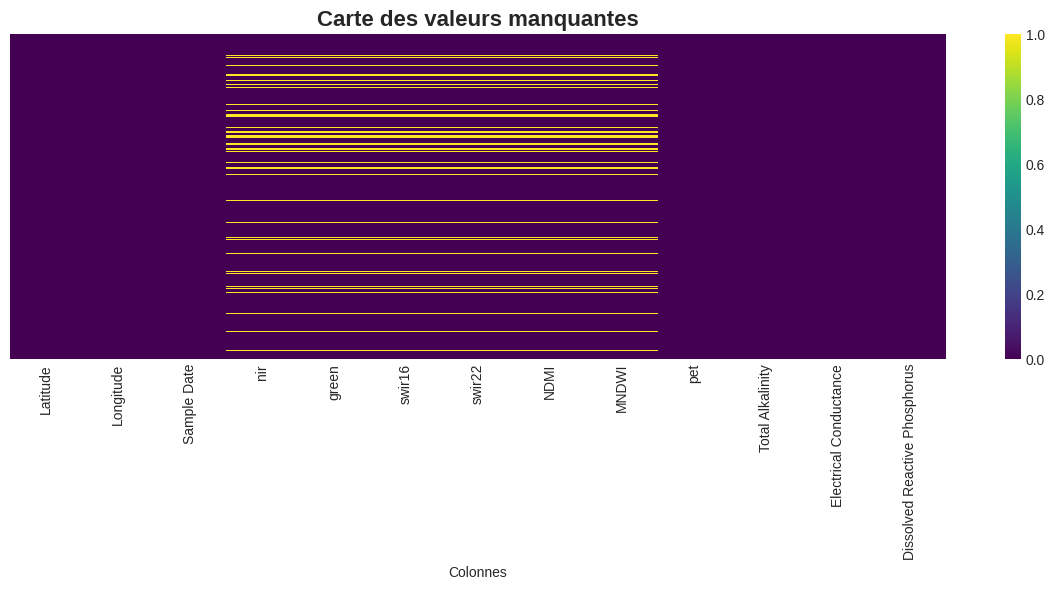

In [107]:
# Analyse des valeurs manquantes
missing_data = pd.DataFrame({
    'Colonne': train_data.columns,
    'Valeurs manquantes': train_data.isnull().sum(),
    'Pourcentage (%)': (train_data.isnull().sum() / len(train_data)) * 100
})
missing_data = missing_data[missing_data['Valeurs manquantes'] > 0].sort_values(
    'Pourcentage (%)', ascending=False
)

print("\n" + "=" * 80)
print("VALEURS MANQUANTES")
print("=" * 80)
if len(missing_data) == 0:
    print("Aucune valeur manquante detectee!")
else:
    print(missing_data.to_string(index=False))

# Visualisation des valeurs manquantes
plt.figure(figsize=(12, 6))
sns.heatmap(train_data.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Carte des valeurs manquantes', fontsize=16, fontweight='bold')
plt.xlabel('Colonnes')
plt.tight_layout()
plt.show()

### 3.3 Distribution des variables cibles

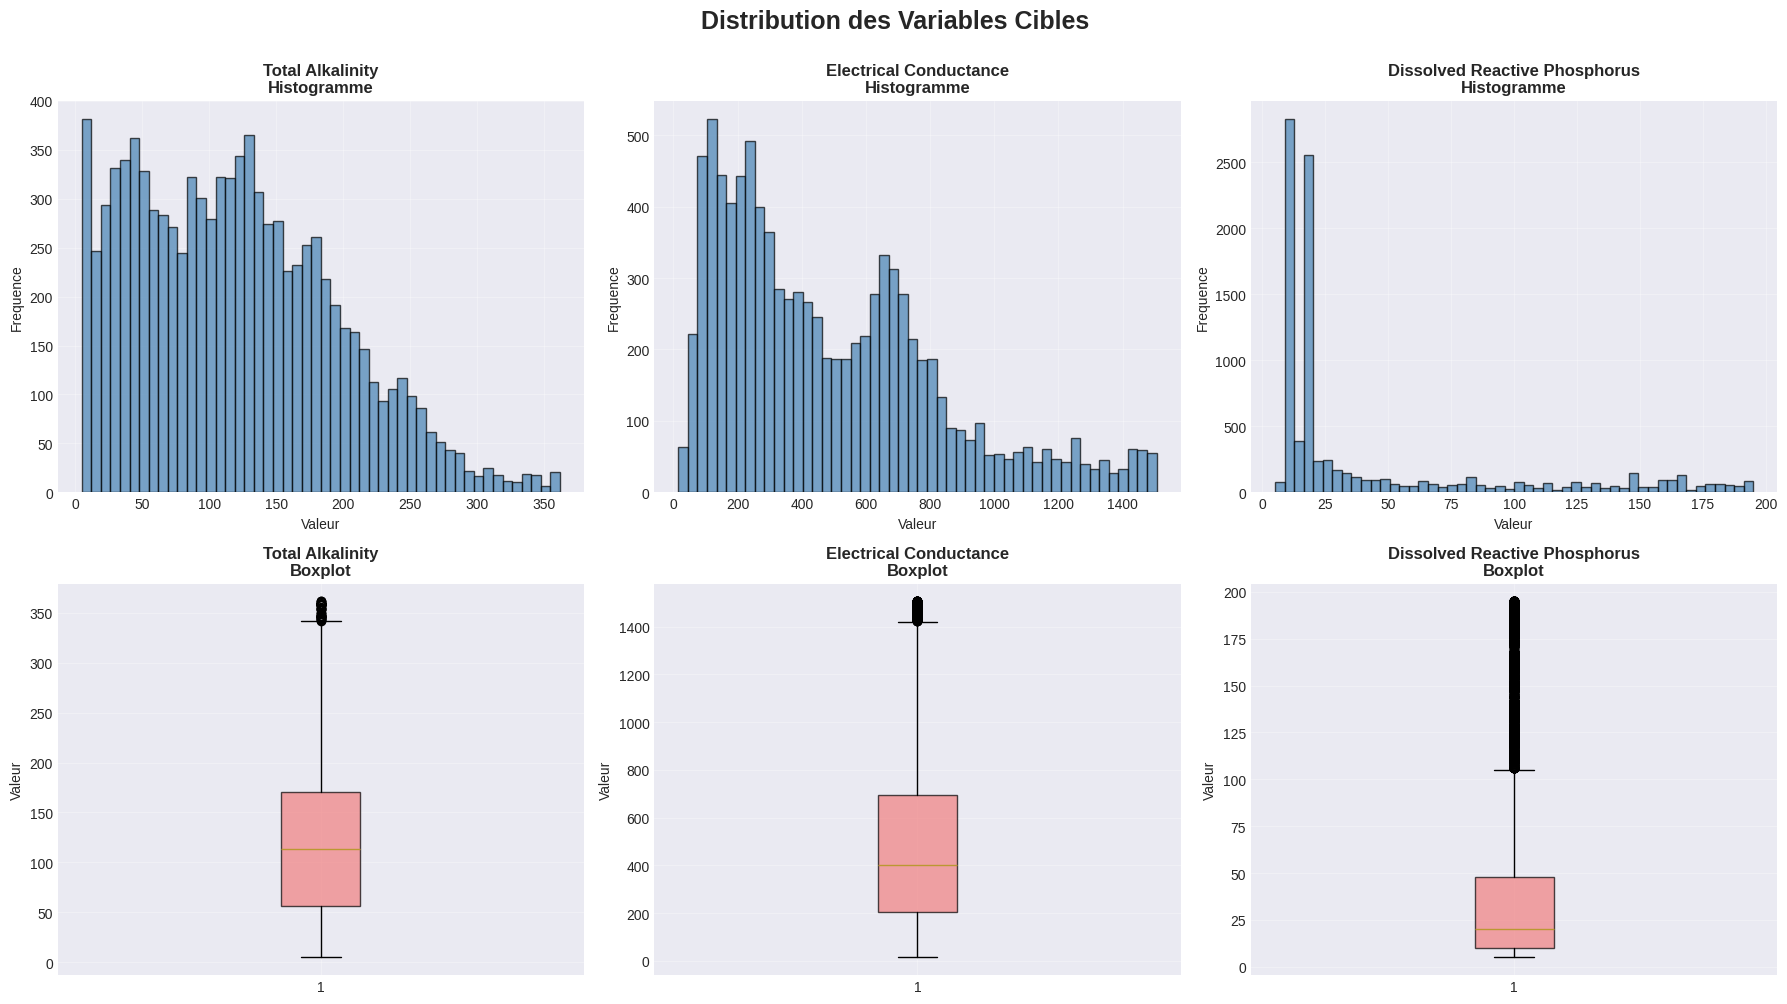


STATISTIQUES DES VARIABLES CIBLES

Total Alkalinity:
  - Min: 4.80
  - Max: 361.68
  - Moyenne: 119.11
  - Mediane: 113.30
  - Ecart-type: 74.69

Electrical Conductance:
  - Min: 15.12
  - Max: 1506.00
  - Moyenne: 485.00
  - Mediane: 402.00
  - Ecart-type: 341.94

Dissolved Reactive Phosphorus:
  - Min: 5.00
  - Max: 195.00
  - Moyenne: 43.53
  - Mediane: 20.00
  - Ecart-type: 50.98


In [108]:
# Variables cibles
target_cols = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

# Creation des sous-graphiques
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution des Variables Cibles', fontsize=18, fontweight='bold', y=1.00)

for idx, target in enumerate(target_cols):
    # Histogramme
    axes[0, idx].hist(train_data[target].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'{target}\nHistogramme', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel('Valeur')
    axes[0, idx].set_ylabel('Frequence')
    axes[0, idx].grid(True, alpha=0.3)
    
    # Boxplot
    axes[1, idx].boxplot(train_data[target].dropna(), vert=True, patch_artist=True,
                         boxprops=dict(facecolor='lightcoral', alpha=0.7))
    axes[1, idx].set_title(f'{target}\nBoxplot', fontsize=12, fontweight='bold')
    axes[1, idx].set_ylabel('Valeur')
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiques sur les cibles
print("\n" + "=" * 80)
print("STATISTIQUES DES VARIABLES CIBLES")
print("=" * 80)
for target in target_cols:
    data = train_data[target].dropna()
    print(f"\n{target}:")
    print(f"  - Min: {data.min():.2f}")
    print(f"  - Max: {data.max():.2f}")
    print(f"  - Moyenne: {data.mean():.2f}")
    print(f"  - Mediane: {data.median():.2f}")
    print(f"  - Ecart-type: {data.std():.2f}")

### 3.4 Matrice de correlation

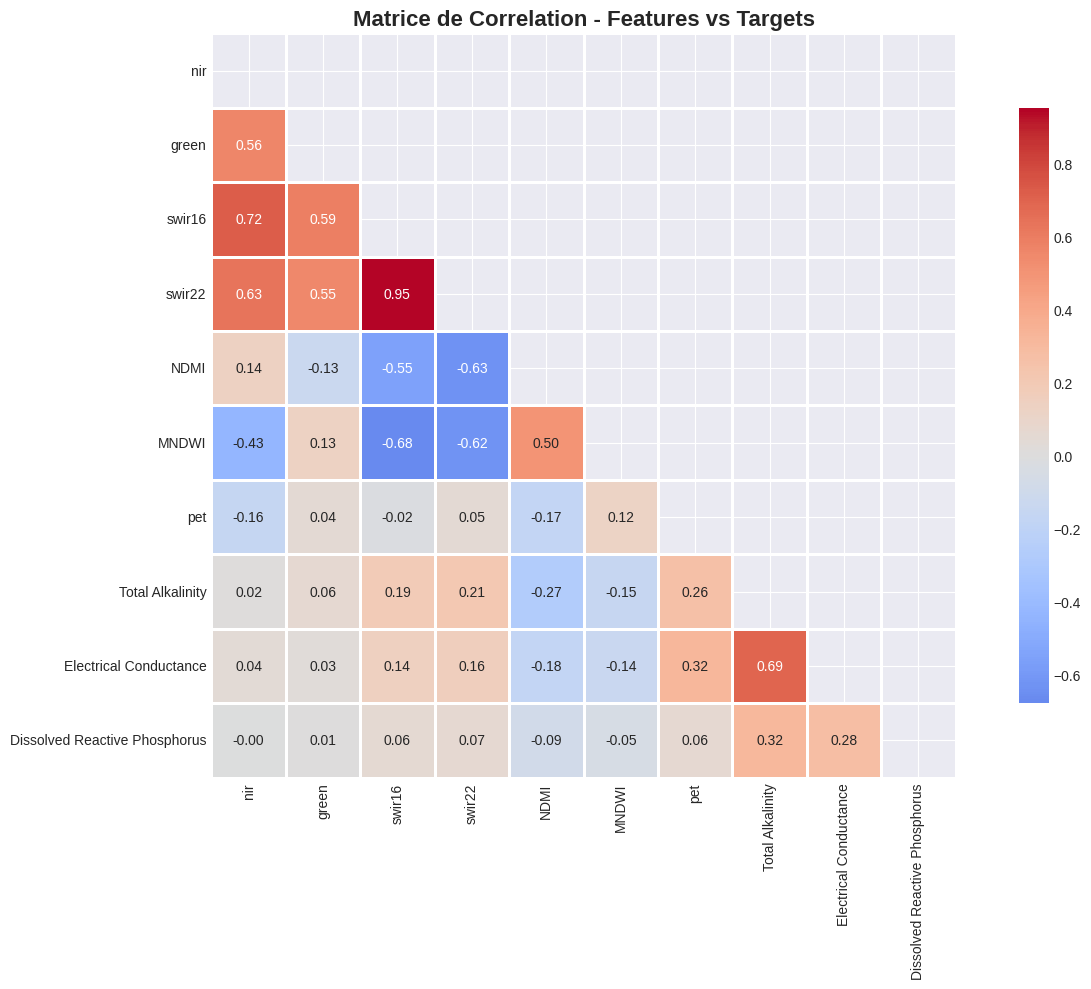


CORRELATIONS FEATURES <-> TARGETS

Total Alkalinity:
Total Alkalinity    1.000000
pet                 0.263515
swir22              0.211446
swir16              0.191913
green               0.061622
nir                 0.015579
MNDWI              -0.154614

Electrical Conductance:
Electrical Conductance    1.000000
pet                       0.322811
swir22                    0.159797
swir16                    0.144659
nir                       0.037289
green                     0.028293
MNDWI                    -0.141569

Dissolved Reactive Phosphorus:
Dissolved Reactive Phosphorus    1.000000
swir22                           0.065900
pet                              0.062566
swir16                           0.059861
green                            0.008321
nir                             -0.004762
MNDWI                           -0.048319


In [109]:
# Features numeriques
feature_cols = ['nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'pet']

# Selection des colonnes numeriques pour la correlation
numeric_cols = feature_cols + target_cols
correlation_data = train_data[numeric_cols].corr()

# Visualisation de la matrice de correlation
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_data, dtype=bool))
sns.heatmap(
    correlation_data, 
    mask=mask,
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
plt.title('Matrice de Correlation - Features vs Targets', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlations avec les targets
print("\n" + "=" * 80)
print("CORRELATIONS FEATURES <-> TARGETS")
print("=" * 80)
for target in target_cols:
    print(f"\n{target}:")
    corr = train_data[feature_cols + [target]].corr()[target].sort_values(ascending=False)
    print(corr[:-1].to_string())

---
## 4. Nettoyage & Preprocessing des donnees {#section4}

In [110]:
# Verification detaillee des valeurs manquantes dans le train
print("=" * 80)
print("GESTION DES VALEURS MANQUANTES")
print("=" * 80)

missing_train = train_data.isnull().sum()
print(f"\nValeurs manquantes dans le train set:")
print(missing_train[missing_train > 0])

# Suppression des lignes avec valeurs manquantes
train_data_clean = train_data.dropna().copy()
print(f"\nLignes supprimees: {len(train_data) - len(train_data_clean)}")
print(f"Donnees restantes: {len(train_data_clean)} lignes")

# Verification des valeurs manquantes dans test
missing_test = test_features.isnull().sum()
print(f"\nValeurs manquantes dans le test set:")
print(missing_test[missing_test > 0])

# Imputation si necessaire dans test
if test_features.isnull().sum().sum() > 0:
    print("\nImputation des valeurs manquantes dans le test set...")
    for col in test_features.columns:
        if test_features[col].isnull().sum() > 0:
            if test_features[col].dtype in ['float64', 'int64']:
                test_features[col].fillna(test_features[col].median(), inplace=True)
    print("Imputation terminee!")

GESTION DES VALEURS MANQUANTES

Valeurs manquantes dans le train set:
nir       1085
green     1085
swir16    1085
swir22    1085
NDMI      1085
MNDWI     1085
dtype: int64

Lignes supprimees: 1085
Donnees restantes: 8234 lignes

Valeurs manquantes dans le test set:
nir       19
green     19
swir16    19
swir22    19
NDMI      19
MNDWI     19
dtype: int64

Imputation des valeurs manquantes dans le test set...
Imputation terminee!


In [111]:
# Verification des doublons
duplicates = train_data_clean.duplicated().sum()
print("\n" + "=" * 80)
print("VERIFICATION DES DUPLICATAS")
print("=" * 80)
print(f"\nNombre de lignes dupliquees: {duplicates}")

if duplicates > 0:
    train_data_clean = train_data_clean.drop_duplicates()
    print(f"{duplicates} lignes dupliquees supprimees")
else:
    print("Aucun duplicata detecte")

print(f"\nDataset final apres nettoyage: {train_data_clean.shape}")


VERIFICATION DES DUPLICATAS

Nombre de lignes dupliquees: 0
Aucun duplicata detecte

Dataset final apres nettoyage: (8234, 13)


---
## 5. Feature Engineering {#section5}

In [112]:
def create_features(df):
    """
    Cree de nouvelles features pertinentes pour la prediction de qualite de l'eau
    """
    df = df.copy()
    
    # === Features temporelles ===
    df['Date_parsed'] = pd.to_datetime(df['Sample Date'], format='%d-%m-%Y')
    df['Year'] = df['Date_parsed'].dt.year
    df['Month'] = df['Date_parsed'].dt.month
    df['Day'] = df['Date_parsed'].dt.day
    df['Day_of_year'] = df['Date_parsed'].dt.dayofyear
    df['Quarter'] = df['Date_parsed'].dt.quarter
    df['Week_of_year'] = df['Date_parsed'].dt.isocalendar().week.astype(int)
    
    # Season (saisons de l'hemisphere sud)
    df['Season'] = df['Month'].apply(lambda x: 
        1 if x in [12, 1, 2] else  # Ete
        2 if x in [3, 4, 5] else   # Automne
        3 if x in [6, 7, 8] else   # Hiver
        4)                          # Printemps
    
    # === Features spectrales derivees ===
    # Normalized Difference Vegetation Index
    df['NDVI'] = (df['nir'] - df['green']) / (df['nir'] + df['green'] + 1e-8)
    
    # Enhanced Vegetation Index
    df['EVI'] = 2.5 * ((df['nir'] - df['green']) / 
                       (df['nir'] + 6 * df['green'] - 7.5 * df['swir22'] + 1 + 1e-8))
    
    # Normalized Difference Turbidity Index
    df['NDTI'] = (df['green'] - df['swir16']) / (df['green'] + df['swir16'] + 1e-8)
    
    # Water Index
    df['WI'] = (df['green'] + df['nir']) / (df['swir16'] + df['swir22'] + 1e-8)
    
    # Ratios spectraux
    df['nir_green_ratio'] = df['nir'] / (df['green'] + 1e-8)
    df['swir_ratio'] = df['swir22'] / (df['swir16'] + 1e-8)
    df['green_nir_ratio'] = df['green'] / (df['nir'] + 1e-8)
    
    # === Features d'interaction ===
    df['NDMI_pet'] = df['NDMI'] * df['pet']
    df['MNDWI_pet'] = df['MNDWI'] * df['pet']
    df['nir_pet'] = df['nir'] * df['pet']
    
    # === Features geospatiales ===
    # Distance from a reference point (approximate center of South Africa)
    ref_lat, ref_lon = -29.0, 24.0
    df['distance_from_center'] = np.sqrt(
        (df['Latitude'] - ref_lat)**2 + (df['Longitude'] - ref_lon)**2
    )
    
    # Interaction Lat-Long
    df['lat_lon_interaction'] = df['Latitude'] * df['Longitude']
    
    # === Features polynomiales ===
    df['pet_squared'] = df['pet'] ** 2
    df['NDMI_squared'] = df['NDMI'] ** 2
    df['MNDWI_squared'] = df['MNDWI'] ** 2
    
    return df

# Application du feature engineering
print("=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)
print("\nCreation des nouvelles features...")

train_data_fe = create_features(train_data_clean)
test_features_fe = create_features(test_features)

# Nouvelles features creees
original_features = set(train_data_clean.columns)
new_features = set(train_data_fe.columns) - original_features
print(f"\n{len(new_features)} nouvelles features creees:")
for i, feat in enumerate(sorted(new_features), 1):
    print(f"   {i}. {feat}")

print(f"\nShape apres feature engineering:")
print(f"   - Train: {train_data_fe.shape}")
print(f"   - Test: {test_features_fe.shape}")

FEATURE ENGINEERING

Creation des nouvelles features...

23 nouvelles features creees:
   1. Date_parsed
   2. Day
   3. Day_of_year
   4. EVI
   5. MNDWI_pet
   6. MNDWI_squared
   7. Month
   8. NDMI_pet
   9. NDMI_squared
   10. NDTI
   11. NDVI
   12. Quarter
   13. Season
   14. WI
   15. Week_of_year
   16. Year
   17. distance_from_center
   18. green_nir_ratio
   19. lat_lon_interaction
   20. nir_green_ratio
   21. nir_pet
   22. pet_squared
   23. swir_ratio

Shape apres feature engineering:
   - Train: (8234, 36)
   - Test: (200, 33)


---
## 6. Preparation des donnees pour l'entrainement {#section6}

In [113]:
# Definition des colonnes a exclure
exclude_cols = ['Sample Date', 'Date_parsed', 'Total Alkalinity', 
                'Electrical Conductance', 'Dissolved Reactive Phosphorus']

# Features finales
feature_columns = [col for col in train_data_fe.columns if col not in exclude_cols]

print("=" * 80)
print("FEATURES FINALES POUR LA MODELISATION")
print("=" * 80)
print(f"\nNombre total de features: {len(feature_columns)}")

# Separation features et targets
X = train_data_fe[feature_columns].copy()
y = train_data_fe[target_cols].copy()

# Features pour le test
X_test = test_features_fe[feature_columns].copy()

print(f"\nX (features): {X.shape}")
print(f"y (targets): {y.shape}")
print(f"X_test (features test): {X_test.shape}")

# Verification finale des NaN
print(f"\nVerification des valeurs manquantes:")
print(f"   - X: {X.isnull().sum().sum()} NaN")
print(f"   - y: {y.isnull().sum().sum()} NaN")
print(f"   - X_test: {X_test.isnull().sum().sum()} NaN")

FEATURES FINALES POUR LA MODELISATION

Nombre total de features: 31



X (features): (8234, 31)
y (targets): (8234, 3)
X_test (features test): (200, 31)

Verification des valeurs manquantes:
   - X: 0 NaN
   - y: 0 NaN
   - X_test: 0 NaN


In [114]:
# Normalisation des donnees avec RobustScaler (robuste aux outliers)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

print("\n" + "=" * 80)
print("NORMALISATION DES DONNEES")
print("=" * 80)
print("\nRobustScaler applique (robuste aux outliers)")
print(f"   - X_scaled: {X_scaled.shape}")
print(f"   - X_test_scaled: {X_test_scaled.shape}")


NORMALISATION DES DONNEES

RobustScaler applique (robuste aux outliers)
   - X_scaled: (8234, 31)
   - X_test_scaled: (200, 31)


---
## 7. Modelisation avec Cross-Validation {#section7}

### 7.1 Configuration de la Cross-Validation

In [115]:
# Configuration du K-Fold
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print("=" * 80)
print("CONFIGURATION CROSS-VALIDATION")
print("=" * 80)
print(f"\nMethode: K-Fold")
print(f"Nombre de folds: {N_FOLDS}")
print(f"Shuffle: True")
print(f"Random state: 42")

CONFIGURATION CROSS-VALIDATION

Methode: K-Fold
Nombre de folds: 5
Shuffle: True
Random state: 42


In [116]:
def cross_validate_model(model, X, y, kf, model_name="Model"):
    """
    Effectue une cross-validation complete pour un modele multi-output
    Retourne les scores CV et les predictions OOF (Out-of-Fold)
    Affiche aussi les scores d'entrainement pour detecter l'overfitting
    """
    results = {}
    oof_predictions = np.zeros((len(X), len(target_cols)))
    
    print(f"\n{'=' * 80}")
    print(f"CROSS-VALIDATION - {model_name}")
    print(f"{'=' * 80}")
    
    for idx, target in enumerate(target_cols):
        print(f"\n--- {target} ---")
        
        # Listes pour stocker les scores par fold
        train_r2_scores = []
        train_rmse_scores = []
        train_mae_scores = []
        val_r2_scores = []
        val_rmse_scores = []
        val_mae_scores = []
        
        # Cross-validation manuelle pour obtenir train et val scores
        for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
            X_train_fold = X[train_idx] if isinstance(X, np.ndarray) else X.iloc[train_idx]
            X_val_fold = X[val_idx] if isinstance(X, np.ndarray) else X.iloc[val_idx]
            y_train_fold = y.iloc[train_idx, idx]
            y_val_fold = y.iloc[val_idx, idx]
            
            # Clone du modele pour chaque fold
            from sklearn.base import clone
            model_clone = clone(model)
            model_clone.fit(X_train_fold, y_train_fold)
            
            # Predictions
            y_train_pred = model_clone.predict(X_train_fold)
            y_val_pred = model_clone.predict(X_val_fold)
            
            # Scores Train
            train_r2_scores.append(r2_score(y_train_fold, y_train_pred))
            train_rmse_scores.append(np.sqrt(mean_squared_error(y_train_fold, y_train_pred)))
            train_mae_scores.append(mean_absolute_error(y_train_fold, y_train_pred))
            
            # Scores Validation
            val_r2_scores.append(r2_score(y_val_fold, y_val_pred))
            val_rmse_scores.append(np.sqrt(mean_squared_error(y_val_fold, y_val_pred)))
            val_mae_scores.append(mean_absolute_error(y_val_fold, y_val_pred))
            
            # OOF predictions
            oof_predictions[val_idx, idx] = y_val_pred
        
        # Calcul des moyennes
        mean_train_r2 = np.mean(train_r2_scores)
        std_train_r2 = np.std(train_r2_scores)
        mean_train_rmse = np.mean(train_rmse_scores)
        mean_train_mae = np.mean(train_mae_scores)
        
        mean_val_r2 = np.mean(val_r2_scores)
        std_val_r2 = np.std(val_r2_scores)
        mean_val_rmse = np.mean(val_rmse_scores)
        mean_val_mae = np.mean(val_mae_scores)
        
        # Calcul du gap (indicateur d'overfitting)
        r2_gap = mean_train_r2 - mean_val_r2
        
        results[target] = {
            'Train_R2': mean_train_r2,
            'Train_R2_std': std_train_r2,
            'Train_RMSE': mean_train_rmse,
            'Train_MAE': mean_train_mae,
            'R2': mean_val_r2,
            'R2_std': std_val_r2,
            'RMSE': mean_val_rmse,
            'MAE': mean_val_mae,
            'R2_gap': r2_gap,
            'cv_scores_r2': np.array(val_r2_scores),
            'train_scores_r2': np.array(train_r2_scores)
        }
        
        print(f"  TRAIN -> R2 = {mean_train_r2:.4f} (+/- {std_train_r2:.4f}), RMSE = {mean_train_rmse:.2f}, MAE = {mean_train_mae:.2f}")
        print(f"  VAL   -> R2 = {mean_val_r2:.4f} (+/- {std_val_r2:.4f}), RMSE = {mean_val_rmse:.2f}, MAE = {mean_val_mae:.2f}")
        print(f"  GAP   -> R2 = {r2_gap:.4f} {' OVERFITTING' if r2_gap > 0.1 else ' OK'}")
    
    # Moyenne globale
    avg_train_r2 = np.mean([results[t]['Train_R2'] for t in target_cols])
    avg_val_r2 = np.mean([results[t]['R2'] for t in target_cols])
    avg_train_rmse = np.mean([results[t]['Train_RMSE'] for t in target_cols])
    avg_val_rmse = np.mean([results[t]['RMSE'] for t in target_cols])
    avg_train_mae = np.mean([results[t]['Train_MAE'] for t in target_cols])
    avg_val_mae = np.mean([results[t]['MAE'] for t in target_cols])
    avg_gap = avg_train_r2 - avg_val_r2
    
    results['AVERAGE'] = {
        'Train_R2': avg_train_r2,
        'R2': avg_val_r2,
        'Train_RMSE': avg_train_rmse,
        'RMSE': avg_val_rmse,
        'Train_MAE': avg_train_mae,
        'MAE': avg_val_mae,
        'R2_gap': avg_gap
    }
    
    print(f"\n--- MOYENNE GLOBALE ---")
    print(f"  TRAIN -> R2 = {avg_train_r2:.4f}, RMSE = {avg_train_rmse:.2f}, MAE = {avg_train_mae:.2f}")
    print(f"  VAL   -> R2 = {avg_val_r2:.4f}, RMSE = {avg_val_rmse:.2f}, MAE = {avg_val_mae:.2f}")
    print(f"  GAP   -> R2 = {avg_gap:.4f} {' OVERFITTING DETECTE' if avg_gap > 0.1 else 'PAS D OVERFITTING SIGNIFICATIF'}")
    
    return results, oof_predictions

print("Fonction de cross-validation definie (avec detection d'overfitting)!")

Fonction de cross-validation definie (avec detection d'overfitting)!


### 7.2 Random Forest

In [117]:
# Hyperparametres Random Forest
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=5,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

# Cross-validation
rf_results, rf_oof = cross_validate_model(rf_model, X_scaled, y, kf, "Random Forest")


CROSS-VALIDATION - Random Forest

--- Total Alkalinity ---


  TRAIN -> R2 = 0.8704 (+/- 0.0017), RMSE = 26.98, MAE = 18.91
  VAL   -> R2 = 0.8156 (+/- 0.0127), RMSE = 32.16, MAE = 22.45
  GAP   -> R2 = 0.0548  OK

--- Electrical Conductance ---
  TRAIN -> R2 = 0.8832 (+/- 0.0034), RMSE = 117.47, MAE = 76.17
  VAL   -> R2 = 0.8323 (+/- 0.0142), RMSE = 140.63, MAE = 90.89
  GAP   -> R2 = 0.0509  OK

--- Dissolved Reactive Phosphorus ---
  TRAIN -> R2 = 0.7591 (+/- 0.0033), RMSE = 25.13, MAE = 15.53
  VAL   -> R2 = 0.6509 (+/- 0.0137), RMSE = 30.22, MAE = 18.76
  GAP   -> R2 = 0.1082  OVERFITTING

--- MOYENNE GLOBALE ---
  TRAIN -> R2 = 0.8376, RMSE = 56.53, MAE = 36.87
  VAL   -> R2 = 0.7663, RMSE = 67.67, MAE = 44.03
  GAP   -> R2 = 0.0713 PAS D OVERFITTING SIGNIFICATIF


### 7.3 XGBoost

In [118]:
# Hyperparametres XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.001,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

# Cross-validation
xgb_results, xgb_oof = cross_validate_model(xgb_model, X_scaled, y, kf, "XGBoost")


CROSS-VALIDATION - XGBoost

--- Total Alkalinity ---
  TRAIN -> R2 = 0.3157 (+/- 0.0022), RMSE = 62.00, MAE = 50.66
  VAL   -> R2 = 0.3066 (+/- 0.0061), RMSE = 62.41, MAE = 50.97
  GAP   -> R2 = 0.0091  OK

--- Electrical Conductance ---
  TRAIN -> R2 = 0.3154 (+/- 0.0017), RMSE = 284.42, MAE = 231.16
  VAL   -> R2 = 0.3077 (+/- 0.0051), RMSE = 285.97, MAE = 232.32
  GAP   -> R2 = 0.0077  OK

--- Dissolved Reactive Phosphorus ---
  TRAIN -> R2 = 0.2470 (+/- 0.0030), RMSE = 44.43, MAE = 34.05
  VAL   -> R2 = 0.2319 (+/- 0.0052), RMSE = 44.85, MAE = 34.37
  GAP   -> R2 = 0.0151  OK

--- MOYENNE GLOBALE ---
  TRAIN -> R2 = 0.2927, RMSE = 130.28, MAE = 105.29
  VAL   -> R2 = 0.2821, RMSE = 131.08, MAE = 105.88
  GAP   -> R2 = 0.0106 PAS D OVERFITTING SIGNIFICATIF


### 7.4 LightGBM

In [119]:
# Hyperparametres LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Cross-validation
lgb_results, lgb_oof = cross_validate_model(lgb_model, X_scaled, y, kf, "LightGBM")


CROSS-VALIDATION - LightGBM

--- Total Alkalinity ---
  TRAIN -> R2 = 0.9071 (+/- 0.0008), RMSE = 22.84, MAE = 15.83
  VAL   -> R2 = 0.8393 (+/- 0.0133), RMSE = 30.02, MAE = 20.57
  GAP   -> R2 = 0.0678  OK

--- Electrical Conductance ---
  TRAIN -> R2 = 0.9208 (+/- 0.0037), RMSE = 96.74, MAE = 62.98
  VAL   -> R2 = 0.8541 (+/- 0.0157), RMSE = 131.07, MAE = 83.05
  GAP   -> R2 = 0.0666  OK

--- Dissolved Reactive Phosphorus ---
  TRAIN -> R2 = 0.8216 (+/- 0.0046), RMSE = 21.62, MAE = 13.41
  VAL   -> R2 = 0.6767 (+/- 0.0150), RMSE = 29.08, MAE = 18.02
  GAP   -> R2 = 0.1448  OVERFITTING

--- MOYENNE GLOBALE ---
  TRAIN -> R2 = 0.8831, RMSE = 47.07, MAE = 30.74
  VAL   -> R2 = 0.7901, RMSE = 63.39, MAE = 40.55
  GAP   -> R2 = 0.0931 PAS D OVERFITTING SIGNIFICATIF


---
## 8. Comparaison des Modeles {#section8}

In [120]:
print("\n" + "=" * 80)
print("TABLEAU COMPARATIF DES MODELES (Cross-Validation)")
print("=" * 80)

# Creation du tableau comparatif
all_results = {
    'Random Forest': rf_results,
    'XGBoost': xgb_results,
    'LightGBM': lgb_results
}

comparison_data = []
for model_name, results in all_results.items():
    row = {
        'Modele': model_name,
        'Train R2': results['AVERAGE']['Train_R2'],
        'Val R2': results['AVERAGE']['R2'],
        'R2 Gap': results['AVERAGE']['R2_gap'],
        'Train RMSE': results['AVERAGE']['Train_RMSE'],
        'Val RMSE': results['AVERAGE']['RMSE'],
        'Train MAE': results['AVERAGE']['Train_MAE'],
        'Val MAE': results['AVERAGE']['MAE']
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Val R2', ascending=False)
print("\n", comparison_df.to_string(index=False))

# Analyse de l'overfitting
print(f"\n{'=' * 80}")
print("ANALYSE OVERFITTING")
print("=" * 80)
for _, row in comparison_df.iterrows():
    gap = row['R2 Gap']
    status = " OVERFITTING" if gap > 0.1 else " OK"
    print(f"   {row['Modele']}: Gap R2 = {gap:.4f} -> {status}")

# Identification du meilleur modele
best_model_name = comparison_df.iloc[0]['Modele']
best_r2 = comparison_df.iloc[0]['Val R2']
print(f"\n{'=' * 80}")
print(f"MEILLEUR MODELE: {best_model_name}")
print(f"R2 Moyen CV (Validation): {best_r2:.4f}")
print(f"{'=' * 80}")


TABLEAU COMPARATIF DES MODELES (Cross-Validation)

        Modele  Train R2   Val R2   R2 Gap  Train RMSE   Val RMSE  Train MAE    Val MAE
     LightGBM  0.883145 0.790052 0.093093   47.070087  63.390449  30.738578  40.547058
Random Forest  0.837552 0.766258 0.071294   56.526251  67.673138  36.868174  44.033147
      XGBoost  0.292692 0.282070 0.010622  130.282493 131.075732 105.292590 105.884419

ANALYSE OVERFITTING
   LightGBM: Gap R2 = 0.0931 ->  OK
   Random Forest: Gap R2 = 0.0713 ->  OK
   XGBoost: Gap R2 = 0.0106 ->  OK

MEILLEUR MODELE: LightGBM
R2 Moyen CV (Validation): 0.7901


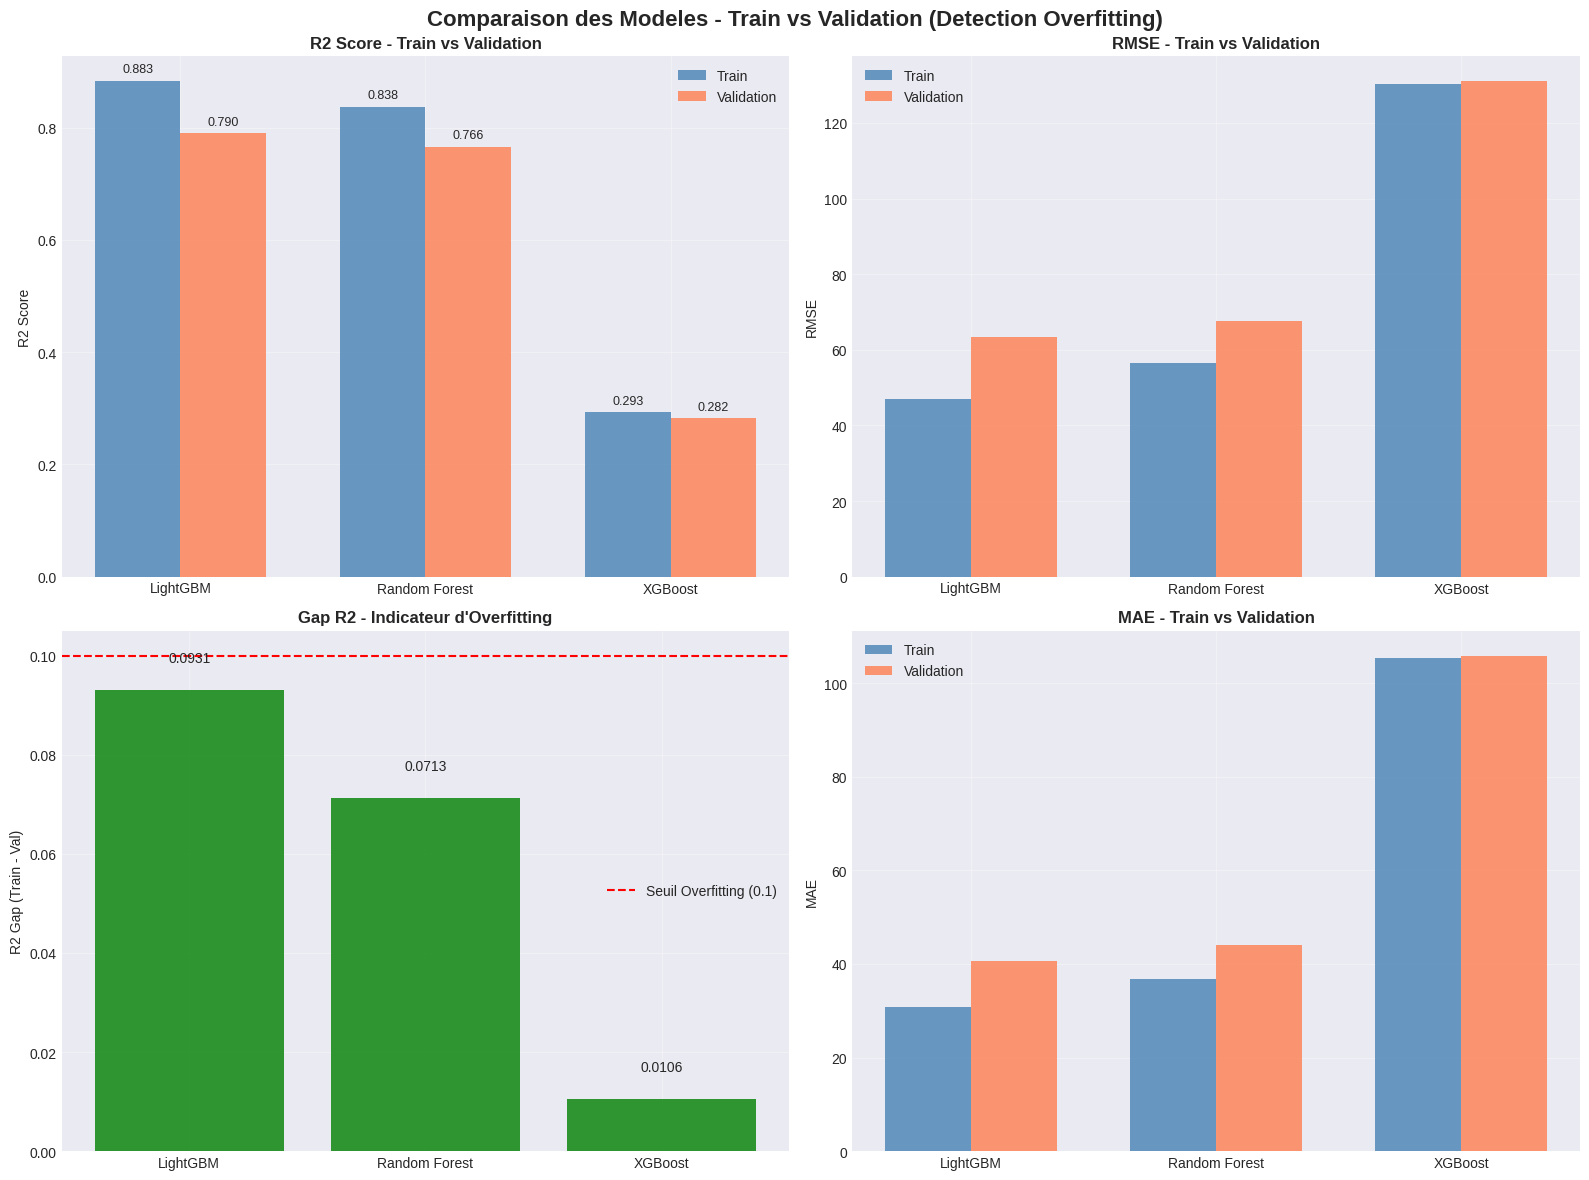

In [121]:
# Visualisation de la comparaison Train vs Validation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparaison des Modeles - Train vs Validation (Detection Overfitting)', fontsize=16, fontweight='bold')

models = comparison_df['Modele'].tolist()
x = np.arange(len(models))
width = 0.35

# R2 Train vs Val
train_r2 = comparison_df['Train R2'].tolist()
val_r2 = comparison_df['Val R2'].tolist()
bars1 = axes[0, 0].bar(x - width/2, train_r2, width, label='Train', color='steelblue', alpha=0.8)
bars2 = axes[0, 0].bar(x + width/2, val_r2, width, label='Validation', color='coral', alpha=0.8)
axes[0, 0].set_ylabel('R2 Score')
axes[0, 0].set_title('R2 Score - Train vs Validation', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
for bar, val in zip(bars1, train_r2):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, val_r2):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# RMSE Train vs Val
train_rmse = comparison_df['Train RMSE'].tolist()
val_rmse = comparison_df['Val RMSE'].tolist()
bars3 = axes[0, 1].bar(x - width/2, train_rmse, width, label='Train', color='steelblue', alpha=0.8)
bars4 = axes[0, 1].bar(x + width/2, val_rmse, width, label='Validation', color='coral', alpha=0.8)
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].set_title('RMSE - Train vs Validation', fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# R2 Gap (Overfitting indicator)
gaps = comparison_df['R2 Gap'].tolist()
colors_gap = ['green' if g <= 0.1 else 'red' for g in gaps]
bars5 = axes[1, 0].bar(models, gaps, color=colors_gap, alpha=0.8)
axes[1, 0].axhline(y=0.1, color='red', linestyle='--', label='Seuil Overfitting (0.1)')
axes[1, 0].set_ylabel('R2 Gap (Train - Val)')
axes[1, 0].set_title('Gap R2 - Indicateur d\'Overfitting', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
for bar, val in zip(bars5, gaps):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# MAE Train vs Val
train_mae = comparison_df['Train MAE'].tolist()
val_mae = comparison_df['Val MAE'].tolist()
bars6 = axes[1, 1].bar(x - width/2, train_mae, width, label='Train', color='steelblue', alpha=0.8)
bars7 = axes[1, 1].bar(x + width/2, val_mae, width, label='Validation', color='coral', alpha=0.8)
axes[1, 1].set_ylabel('MAE')
axes[1, 1].set_title('MAE - Train vs Validation', fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

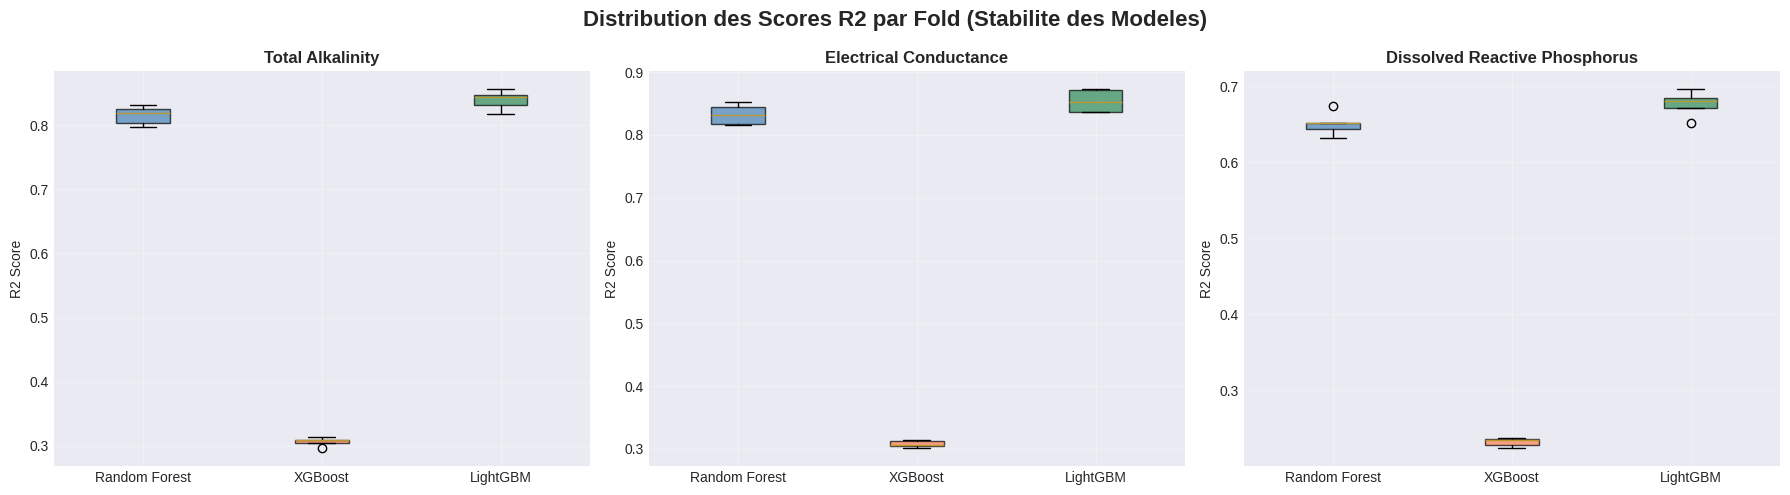

In [122]:
# Visualisation des scores CV par fold pour chaque modele
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution des Scores R2 par Fold (Stabilite des Modeles)', fontsize=16, fontweight='bold')

for idx, target in enumerate(target_cols):
    data_to_plot = []
    labels = []
    for model_name, results in all_results.items():
        data_to_plot.append(results[target]['cv_scores_r2'])
        labels.append(model_name)
    
    bp = axes[idx].boxplot(data_to_plot, labels=labels, patch_artist=True)
    colors_bp = ['steelblue', 'coral', 'seagreen']
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[idx].set_title(f'{target}', fontweight='bold')
    axes[idx].set_ylabel('R2 Score')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Feature Importance {#section9}

In [123]:
# Entrainement des modeles sur tout le dataset pour obtenir feature importance
print("=" * 80)
print("FEATURE IMPORTANCE")
print("=" * 80)

# Entrainer chaque modele sur tout le dataset
xgb_models_fi = []
lgb_models_fi = []

for idx, target in enumerate(target_cols):
    # XGBoost
    xgb_temp = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1, reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1
    )
    xgb_temp.fit(X_scaled, y.iloc[:, idx])
    xgb_models_fi.append(xgb_temp)
    
    # LightGBM
    lgb_temp = lgb.LGBMRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1
    )
    lgb_temp.fit(X_scaled, y.iloc[:, idx])
    lgb_models_fi.append(lgb_temp)

print("Modeles entraines pour l'analyse de feature importance!")

FEATURE IMPORTANCE
Modeles entraines pour l'analyse de feature importance!


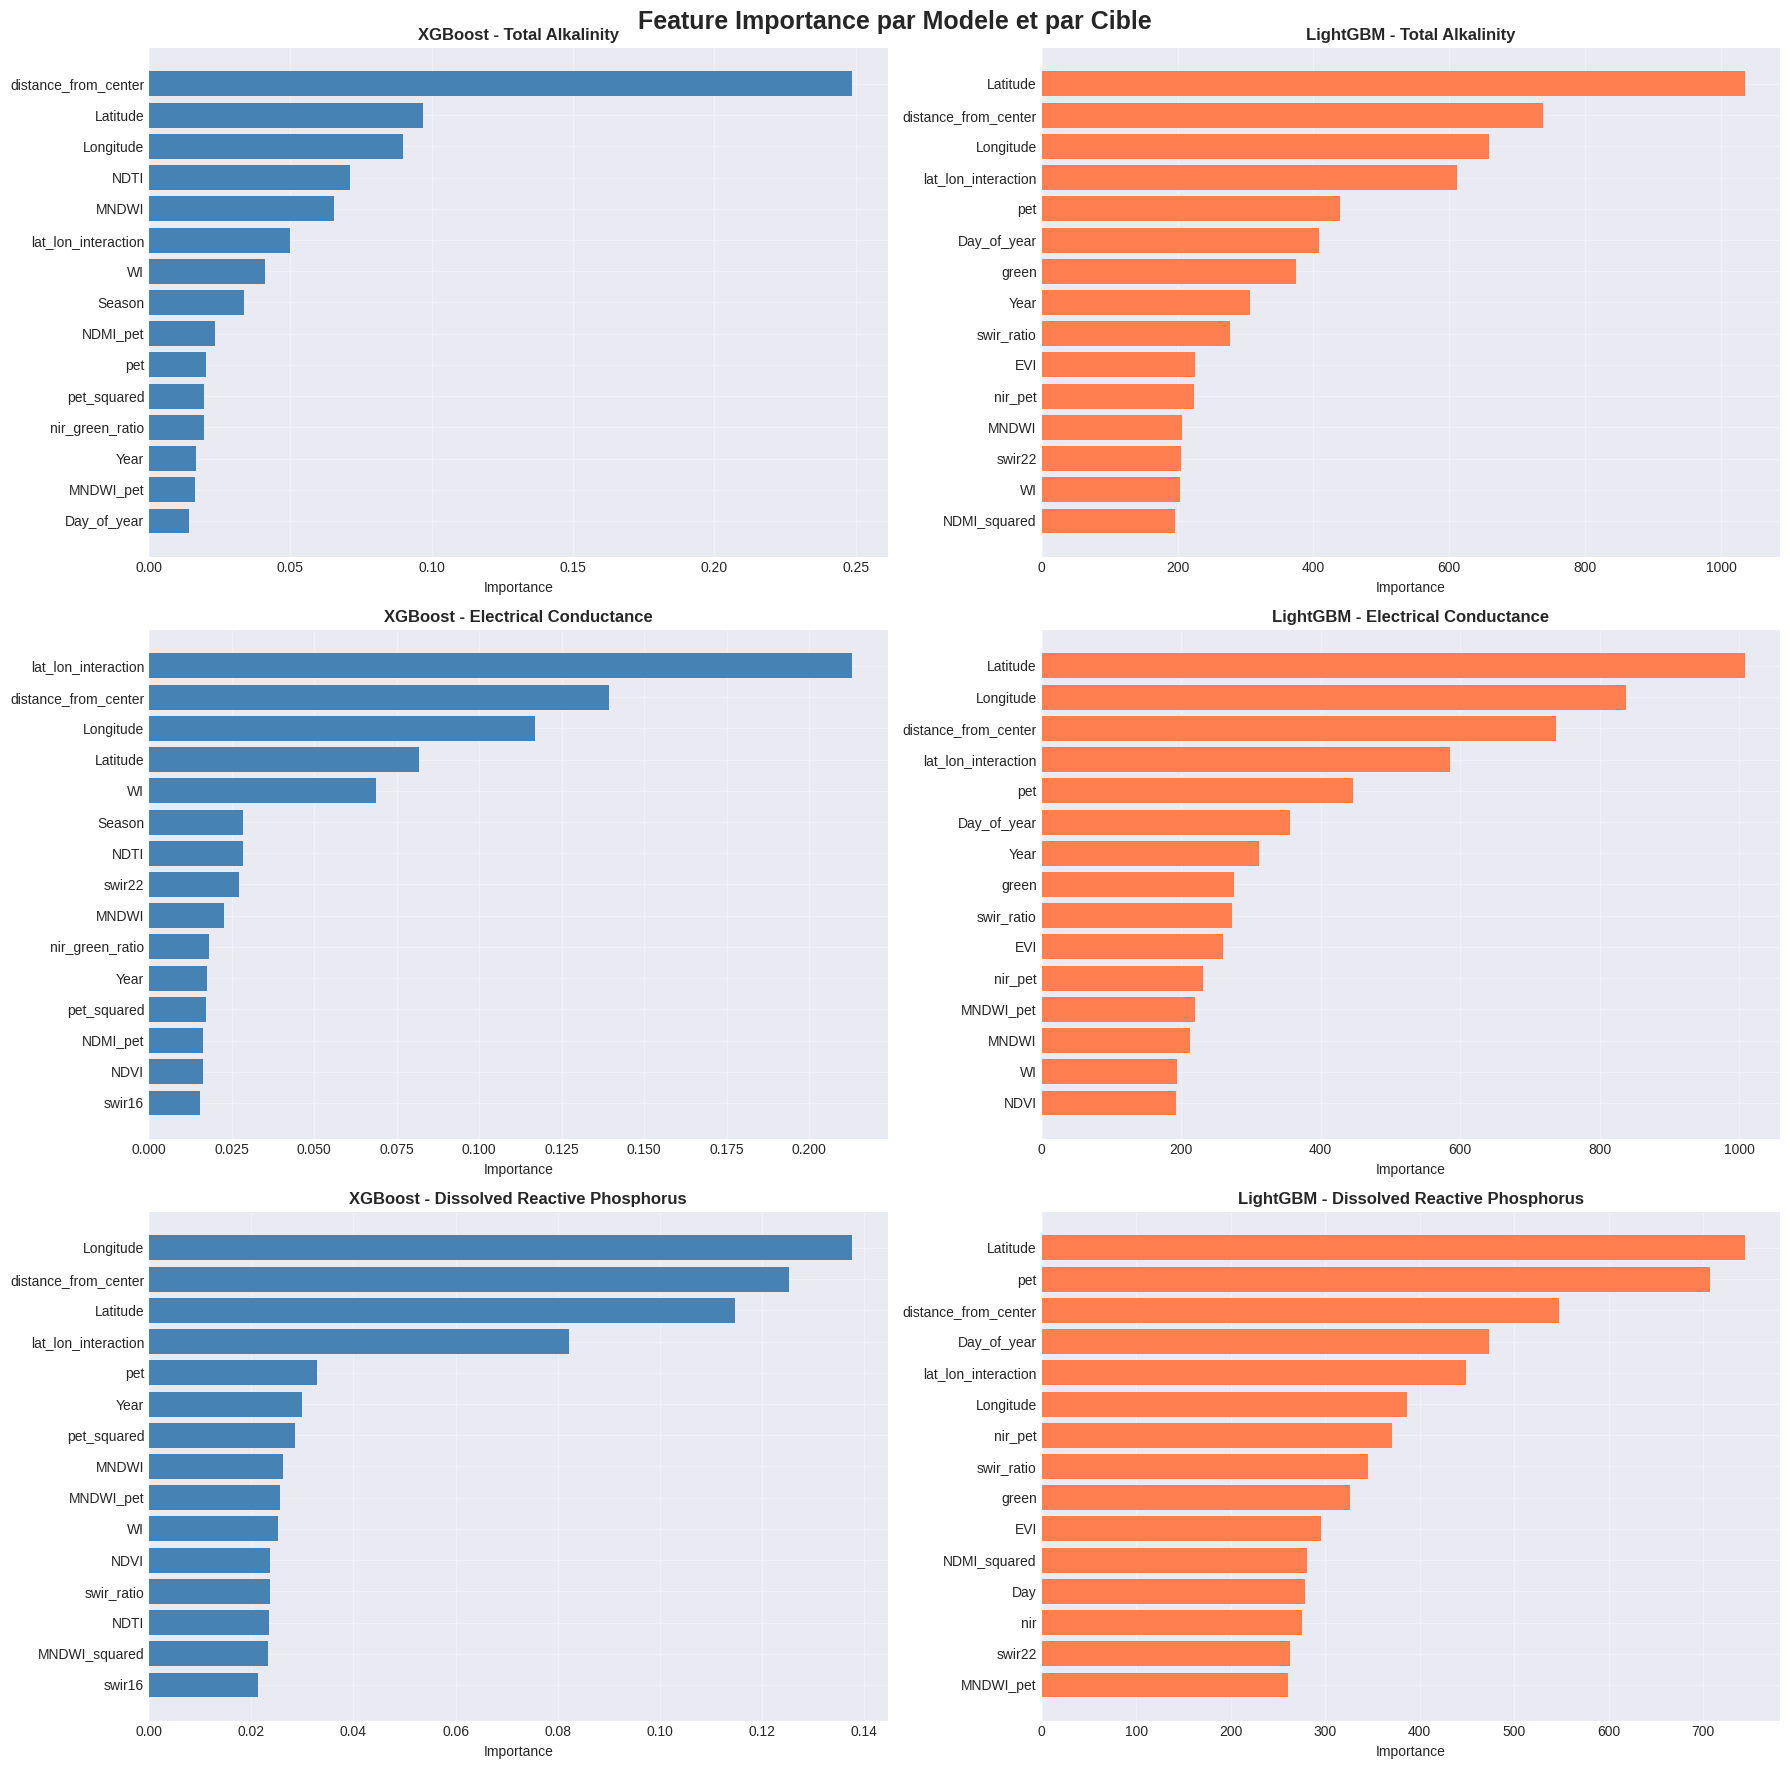

In [124]:
# Visualisation des feature importances
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Feature Importance par Modele et par Cible', fontsize=18, fontweight='bold')

for idx, target in enumerate(target_cols):
    # XGBoost
    xgb_importance = xgb_models_fi[idx].feature_importances_
    xgb_feat_imp = pd.DataFrame({
        'feature': feature_columns,
        'importance': xgb_importance
    }).sort_values('importance', ascending=False).head(15)
    
    axes[idx, 0].barh(xgb_feat_imp['feature'], xgb_feat_imp['importance'], color='steelblue')
    axes[idx, 0].set_title(f'XGBoost - {target}', fontweight='bold')
    axes[idx, 0].set_xlabel('Importance')
    axes[idx, 0].invert_yaxis()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # LightGBM
    lgb_importance = lgb_models_fi[idx].feature_importances_
    lgb_feat_imp = pd.DataFrame({
        'feature': feature_columns,
        'importance': lgb_importance
    }).sort_values('importance', ascending=False).head(15)
    
    axes[idx, 1].barh(lgb_feat_imp['feature'], lgb_feat_imp['importance'], color='coral')
    axes[idx, 1].set_title(f'LightGBM - {target}', fontweight='bold')
    axes[idx, 1].set_xlabel('Importance')
    axes[idx, 1].invert_yaxis()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [125]:
# Top 10 features globales (moyenne sur tous les targets et modeles)
print("\nTOP 10 FEATURES GLOBALES (moyenne XGBoost + LightGBM):")
all_importance = []
for idx in range(len(target_cols)):
    xgb_imp = xgb_models_fi[idx].feature_importances_
    lgb_imp = lgb_models_fi[idx].feature_importances_
    # Normaliser avant de moyenner
    xgb_imp_norm = xgb_imp / xgb_imp.sum()
    lgb_imp_norm = lgb_imp / lgb_imp.sum()
    avg_imp = (xgb_imp_norm + lgb_imp_norm) / 2
    all_importance.append(avg_imp)

global_importance = np.mean(all_importance, axis=0)
global_feat_imp = pd.DataFrame({
    'feature': feature_columns,
    'importance': global_importance
}).sort_values('importance', ascending=False).head(10)

print("-" * 50)
for rank, (_, row) in enumerate(global_feat_imp.iterrows(), 1):
    print(f"   {rank}. {row['feature']}: {row['importance']:.4f}")


TOP 10 FEATURES GLOBALES (moyenne XGBoost + LightGBM):
--------------------------------------------------
   1. distance_from_center: 0.1275
   2. Latitude: 0.1067
   3. Longitude: 0.0966
   4. lat_lon_interaction: 0.0916
   5. pet: 0.0441
   6. WI: 0.0357
   7. Day_of_year: 0.0331
   8. MNDWI: 0.0319
   9. Year: 0.0283
   10. swir_ratio: 0.0270


---
## 10. Entrainement Final & Submission {#section10}

In [131]:
# === 10.1 ANALYSE DISTRIBUTION TRAIN vs TEST ===
print("=" * 80)
print("10.1 ANALYSE DISTRIBUTION TRAIN vs TEST")
print("=" * 80)

print("\n📊 Comparaison des distributions (Train vs Test):")
print(f"{'Feature':<30} {'Train Mean':>12} {'Test Mean':>12} {'Ratio':>10} {'Drift?':>10}")
print("-" * 80)

drift_features = []
for col in feature_columns[:20]:
    train_mean = X[col].mean()
    test_mean = X_test[col].mean()
    if train_mean != 0:
        ratio = abs(test_mean / train_mean)
    else:
        ratio = 1.0
    drift = "⚠️ OUI" if abs(ratio - 1) > 0.5 else "✅ Non"
    if abs(ratio - 1) > 0.5:
        drift_features.append(col)
    print(f"{col:<30} {train_mean:>12.4f} {test_mean:>12.4f} {ratio:>10.2f} {drift:>10}")

print(f"\n📌 Features avec drift significatif (>50%): {len(drift_features)}")
if drift_features:
    print(f"   → {drift_features}")

print(f"\n📊 Statistiques des targets (pour post-processing):")
target_stats = {}
for target in target_cols:
    q1 = y[target].quantile(0.01)
    q99 = y[target].quantile(0.99)
    target_stats[target] = {'min': q1, 'max': q99, 'mean': y[target].mean(), 'std': y[target].std()}
    print(f"\n   {target}:")
    print(f"      Range [P1, P99]: [{q1:.2f}, {q99:.2f}]")
    print(f"      Mean +/- Std: {y[target].mean():.2f} +/- {y[target].std():.2f}")

print(f"\n✅ Analyse terminée - target_stats prêts pour le clipping")

10.1 ANALYSE DISTRIBUTION TRAIN vs TEST

📊 Comparaison des distributions (Train vs Test):
Feature                          Train Mean    Test Mean      Ratio     Drift?
--------------------------------------------------------------------------------
Latitude                           -28.4799     -32.8167       1.15      ✅ Non
Longitude                           26.8992      26.5831       0.99      ✅ Non
nir                              14045.4854   14468.8975       1.03      ✅ Non
green                             9983.2131    9597.3525       0.96      ✅ Non
swir16                           13567.4593   12340.8925       0.91      ✅ Non
swir22                           11425.5384   10266.3000       0.90      ✅ Non
NDMI                                 0.0214       0.0797       3.73     ⚠️ OUI
MNDWI                               -0.1443      -0.1210       0.84      ✅ Non
pet                                174.9538     160.2780       0.92      ✅ Non
Year                              2013.

In [132]:
# === 10.2 ENTRAINEMENT ENSEMBLE ROBUSTE ===
# Stratégie: Combiner RF + XGBoost + LightGBM pour réduire la variance
# Chaque modèle capture des patterns différents => meilleure généralisation

print("=" * 80)
print("10.2 ENTRAINEMENT ENSEMBLE (RF + XGBoost + LightGBM)")
print("=" * 80)

# Log-transform des targets skewed pour stabiliser la variance
from sklearn.base import clone

print("\n📊 Vérification skewness des targets:")
use_log = {}
for target in target_cols:
    skew_val = y[target].skew()
    print(f"   {target}: skewness = {skew_val:.2f}", end="")
    if abs(skew_val) > 1.0 and (y[target] > 0).all():
        use_log[target] = True
        print(" → Log-transform appliqué ✅")
    else:
        use_log[target] = False
        print(" → Pas de transform")

# Préparer les targets (log si nécessaire)
y_transformed = y.copy()
for target in target_cols:
    if use_log[target]:
        y_transformed[target] = np.log1p(y[target])

print(f"\n🔧 Entrainement de 3 modèles sur tout le dataset...")

# === Modèle 1: Random Forest (MEME hyperparamètres que CV) ===
rf_final_models = []
for idx, target in enumerate(target_cols):
    model = RandomForestRegressor(
        n_estimators=150, max_depth=10, min_samples_split=15,
        min_samples_leaf=5, max_features=0.5, random_state=42, n_jobs=-1
    )
    model.fit(X_scaled, y_transformed.iloc[:, idx])
    rf_final_models.append(model)
print("   ✅ Random Forest entraîné (n_estimators=150, max_depth=10)")

# === Modèle 2: XGBoost (MEME hyperparamètres que CV) ===
xgb_final_models = []
for idx, target in enumerate(target_cols):
    model = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.001,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1, reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1
    )
    model.fit(X_scaled, y_transformed.iloc[:, idx])
    xgb_final_models.append(model)
print("   ✅ XGBoost entraîné (n_estimators=300, lr=0.001)")

# === Modèle 3: LightGBM (MEME hyperparamètres que CV) ===
lgb_final_models = []
for idx, target in enumerate(target_cols):
    model = lgb.LGBMRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1
    )
    model.fit(X_scaled, y_transformed.iloc[:, idx])
    lgb_final_models.append(model)
print("   ✅ LightGBM entraîné (n_estimators=300, lr=0.05)")

# Calculer les poids de l'ensemble basés sur les scores CV
print(f"\n📊 Pondération de l'ensemble basée sur les scores CV:")
ensemble_weights = {}
for idx, target in enumerate(target_cols):
    rf_r2 = max(rf_results[target]['R2'], 0)
    xgb_r2 = max(xgb_results[target]['R2'], 0)
    lgb_r2 = max(lgb_results[target]['R2'], 0)
    
    total = rf_r2 + xgb_r2 + lgb_r2
    if total > 0:
        w_rf = rf_r2 / total
        w_xgb = xgb_r2 / total
        w_lgb = lgb_r2 / total
    else:
        w_rf = w_xgb = w_lgb = 1/3
    
    ensemble_weights[target] = (w_rf, w_xgb, w_lgb)
    print(f"   {target}: RF={w_rf:.3f}, XGB={w_xgb:.3f}, LGB={w_lgb:.3f}")

print("\n✅ Ensemble de 3 modèles prêt avec pondération!")

10.2 ENTRAINEMENT ENSEMBLE (RF + XGBoost + LightGBM)

📊 Vérification skewness des targets:
   Total Alkalinity: skewness = 0.53 → Pas de transform
   Electrical Conductance: skewness = 0.92 → Pas de transform
   Dissolved Reactive Phosphorus: skewness = 1.63 → Log-transform appliqué ✅

🔧 Entrainement de 3 modèles sur tout le dataset...
   ✅ Random Forest entraîné (n_estimators=150, max_depth=10)
   ✅ XGBoost entraîné (n_estimators=300, lr=0.001)
   ✅ LightGBM entraîné (n_estimators=300, lr=0.05)

📊 Pondération de l'ensemble basée sur les scores CV:
   Total Alkalinity: RF=0.416, XGB=0.156, LGB=0.428
   Electrical Conductance: RF=0.417, XGB=0.154, LGB=0.428
   Dissolved Reactive Phosphorus: RF=0.417, XGB=0.149, LGB=0.434

✅ Ensemble de 3 modèles prêt avec pondération!


In [133]:
# === 10.3 PREDICTIONS ENSEMBLE + POST-PROCESSING ===
print("=" * 80)
print("10.3 PREDICTIONS ENSEMBLE PONDÉRÉ + POST-PROCESSING")
print("=" * 80)

# Predictions de chaque modele
rf_preds = np.column_stack([m.predict(X_test_scaled) for m in rf_final_models])
xgb_preds = np.column_stack([m.predict(X_test_scaled) for m in xgb_final_models])
lgb_preds = np.column_stack([m.predict(X_test_scaled) for m in lgb_final_models])

# Moyenne ponderee par target
y_test_pred = np.zeros_like(rf_preds)
print("\n🤝 Ensemble pondéré:")
for idx, target in enumerate(target_cols):
    w_rf, w_xgb, w_lgb = ensemble_weights[target]
    y_test_pred[:, idx] = (
        w_rf * rf_preds[:, idx] + 
        w_xgb * xgb_preds[:, idx] + 
        w_lgb * lgb_preds[:, idx]
    )
    print(f"   {target}: RF*{w_rf:.3f} + XGB*{w_xgb:.3f} + LGB*{w_lgb:.3f}")

# Inverse log-transform si applique
print("\n🔄 Inverse log-transform:")
for idx, target in enumerate(target_cols):
    if use_log[target]:
        y_test_pred[:, idx] = np.expm1(y_test_pred[:, idx])
        print(f"   {target}: expm1 appliqué ✅")
    else:
        print(f"   {target}: pas de transform inverse")

# Post-processing: Clipping aux ranges realistes (P1 - P99 du training)
print("\n✂️ Post-processing - Clipping aux ranges réalistes:")
for idx, target in enumerate(target_cols):
    clip_min = target_stats[target]['min']
    clip_max = target_stats[target]['max']
    
    before_clip = y_test_pred[:, idx].copy()
    y_test_pred[:, idx] = np.clip(y_test_pred[:, idx], clip_min, clip_max)
    
    n_clipped = np.sum(before_clip != y_test_pred[:, idx])
    print(f"   {target}: [{clip_min:.2f}, {clip_max:.2f}] -> {n_clipped} valeurs clippées")

# Statistiques finales
print(f"\n📊 STATISTIQUES DES PREDICTIONS FINALES:")
for idx, target in enumerate(target_cols):
    pred_values = y_test_pred[:, idx]
    print(f"\n   {target}:")
    print(f"      Min: {pred_values.min():.2f} | Max: {pred_values.max():.2f}")
    print(f"      Mean: {pred_values.mean():.2f} | Median: {np.median(pred_values):.2f}")
    print(f"      Std: {pred_values.std():.2f}")
    print(f"      Train Mean: {y[target].mean():.2f} | Train Std: {y[target].std():.2f}")

print("\n✅ Predictions ensemble générées et post-traitées!")

10.3 PREDICTIONS ENSEMBLE PONDÉRÉ + POST-PROCESSING

🤝 Ensemble pondéré:
   Total Alkalinity: RF*0.416 + XGB*0.156 + LGB*0.428
   Electrical Conductance: RF*0.417 + XGB*0.154 + LGB*0.428
   Dissolved Reactive Phosphorus: RF*0.417 + XGB*0.149 + LGB*0.434

🔄 Inverse log-transform:
   Total Alkalinity: pas de transform inverse
   Electrical Conductance: pas de transform inverse
   Dissolved Reactive Phosphorus: expm1 appliqué ✅

✂️ Post-processing - Clipping aux ranges réalistes:
   Total Alkalinity: [5.00, 313.58] -> 0 valeurs clippées
   Electrical Conductance: [51.73, 1459.00] -> 0 valeurs clippées
   Dissolved Reactive Phosphorus: [10.00, 191.00] -> 0 valeurs clippées

📊 STATISTIQUES DES PREDICTIONS FINALES:

   Total Alkalinity:
      Min: 54.00 | Max: 232.75
      Mean: 98.00 | Median: 83.33
      Std: 37.55
      Train Mean: 119.15 | Train Std: 74.96

   Electrical Conductance:
      Min: 168.18 | Max: 553.90
      Mean: 321.32 | Median: 290.51
      Std: 88.19
      Train Mean: 48

In [134]:
# === 10.4 CREATION DU FICHIER DE SOUMISSION ===
print("=" * 80)
print("10.4 CREATION DU FICHIER DE SOUMISSION")
print("=" * 80)

# Creation du DataFrame de soumission
submission = submission_template.copy()

# Remplissage avec les predictions ensemble
submission['Total Alkalinity'] = y_test_pred[:, 0]
submission['Electrical Conductance'] = y_test_pred[:, 1]
submission['Dissolved Reactive Phosphorus'] = y_test_pred[:, 2]

# Sauvegarde des modeles
os.makedirs('models', exist_ok=True)
joblib.dump(rf_final_models, 'models/rf_ensemble.pkl')
joblib.dump(xgb_final_models, 'models/xgb_ensemble.pkl')
joblib.dump(lgb_final_models, 'models/lgb_ensemble.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(feature_columns, 'models/feature_columns.pkl')
joblib.dump(ensemble_weights, 'models/ensemble_weights.pkl')
joblib.dump(use_log, 'models/use_log.pkl')
joblib.dump(target_stats, 'models/target_stats.pkl')
print("\n💾 Modèles sauvegardés dans models/")

# Verification
print("\nAperçu du fichier de soumission:")
print(submission.head(10))

# Sauvegarde
submission_filename = 'submission_ensemble_v2.csv'
submission.to_csv(submission_filename, index=False)

print(f"\n{'=' * 80}")
print(f"📤 FICHIER DE SOUMISSION: {submission_filename}")
print(f"{'=' * 80}")
print(f"\n   Stratégie: Ensemble pondéré (RF + XGBoost + LightGBM)")
print(f"   Log-transform: {sum(use_log.values())}/{len(use_log)} targets")
print(f"   Post-processing: Clipping P1-P99")
print(f"   Nombre de predictions: {len(submission)}")
print(f"\n🚀 Prêt pour upload sur Zindi!")

10.4 CREATION DU FICHIER DE SOUMISSION

💾 Modèles sauvegardés dans models/

Aperçu du fichier de soumission:
    Latitude  Longitude Sample Date  Total Alkalinity  Electrical Conductance  \
0 -32.043333  27.822778  01-09-2014         95.897204              263.048836   
1 -33.329167  26.077500  16-09-2015        101.678916              430.927762   
2 -32.991639  27.640028  07-05-2015         71.605635              270.754566   
3 -34.096389  24.439167  07-02-2012         65.697753              352.838469   
4 -32.000556  28.581667  01-10-2014         92.792017              247.166988   
5 -32.086390  25.575560  19-07-2013        178.224969              428.082449   
6 -32.000556  28.581667  03-09-2014         93.635169              238.710407   
7 -32.991639  27.640028  02-10-2014         99.075926              283.908328   
8 -32.000556  28.581667  06-08-2014         97.469007              247.643447   
9 -33.185361  27.390750  22-09-2011         91.674783              282.275298   


---
## Resume Final

### Pipeline realise:

1. **Chargement & Fusion des donnees** (Landsat + TerraClimate + Water Quality)

2. **EDA**: Distribution, correlations, valeurs manquantes

3. **Nettoyage**: Gestion des NaN, duplicatas

4. **Feature Engineering**:
   - Features temporelles (Year, Month, Season, etc.)
   - Indices spectraux (NDVI, EVI, NDTI, WI)
   - Ratios et interactions
   - Features geospatiales et polynomiales

5. **Modelisation avec Cross-Validation (K=5)**:
   - Random Forest
   - XGBoost
   - LightGBM

6. **Selection du meilleur modele** base sur R2 moyen CV

7. **Entrainement final** sur tout le dataset

8. **Generation du fichier de soumission** (submission.csv)

---

### Fichiers generes:
- `submission.csv` - Fichier de soumission pour Zindi
- `models/` - Modeles sauvegardes

---

Bonne chance pour la competition!